<a href="https://colab.research.google.com/github/manalchem/cheme-unit-operations/blob/main/cstr_reactor_simulation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Results & Analysis

- At 400K, conversion is only 7.4% at τ = 5s — the reaction is too slow at low temperature
- At 450K, conversion reaches ~50% — a practical operating point
- At 500K, conversion hits ~88% — higher yield but requires more energy input
- This demonstrates the classic engineering tradeoff: higher temperature = better conversion
  but higher operating costs and safety considerations

### Key Takeaway
Optimal reactor design balances conversion, residence time, and energy cost —
a CSTR operating at 450–500K with τ = 5–8s gives the best practical yield
for ethylene oxide production.


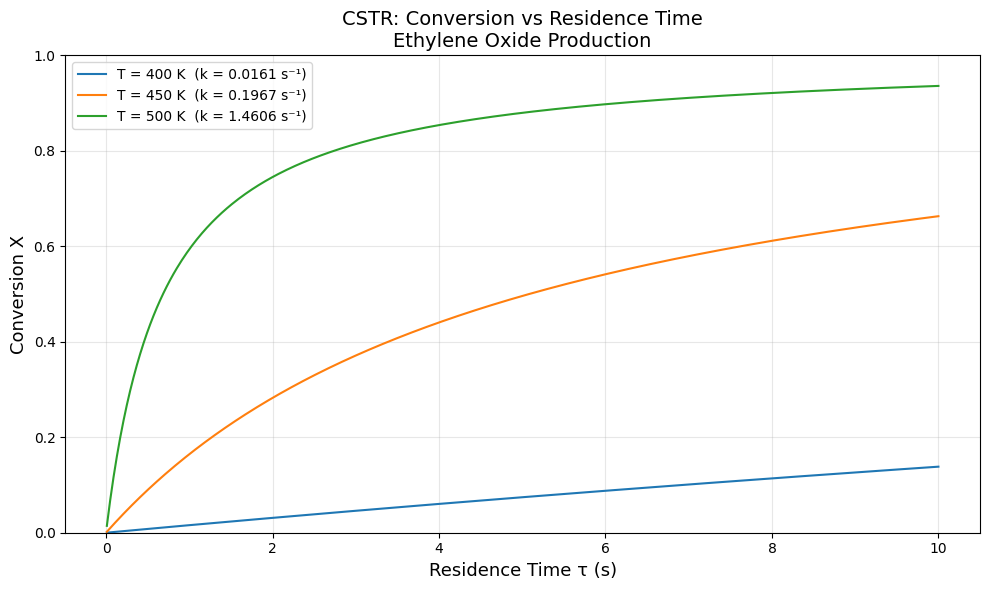


── Steady State Results at τ = 5s ──
T = 400K | k = 0.01606 s⁻¹ | X = 0.0743 | CA = 0.9257 mol/L
T = 450K | k = 0.19675 s⁻¹ | X = 0.4959 | CA = 0.5041 mol/L
T = 500K | k = 1.46057 s⁻¹ | X = 0.8796 | CA = 0.1204 mol/L


In [2]:
import numpy as np
import matplotlib.pyplot as plt

# ── Reaction Parameters ──────────────────────────────────────────
A = 1.0e8        # Pre-exponential factor (1/s)
Ea = 75000       # Activation energy (J/mol)
R = 8.314        # Gas constant (J/mol·K)
CA0 = 1.0        # Initial concentration (mol/L)

# ── Temperature range ────────────────────────────────────────────
temperatures = [400, 450, 500]  # Kelvin
tau = np.linspace(0.01, 10, 500)  # Residence time (s)

# ── CSTR Design Equation ─────────────────────────────────────────
# X = k*tau / (1 + k*tau)  for first-order reaction

plt.figure(figsize=(10, 6))

for T in temperatures:
    k = A * np.exp(-Ea / (R * T))       # Arrhenius rate constant
    X = (k * tau) / (1 + k * tau)       # CSTR conversion
    CA = CA0 * (1 - X)                  # Reactant concentration
    plt.plot(tau, X, label=f'T = {T} K  (k = {k:.4f} s⁻¹)')

plt.xlabel('Residence Time τ (s)', fontsize=13)
plt.ylabel('Conversion X', fontsize=13)
plt.title('CSTR: Conversion vs Residence Time\nEthylene Oxide Production', fontsize=14)
plt.legend()
plt.grid(True, alpha=0.3)
plt.ylim(0, 1)
plt.tight_layout()
plt.savefig('cstr_conversion.png', dpi=150)
plt.show()

print("\n── Steady State Results at τ = 5s ──")
for T in temperatures:
    k = A * np.exp(-Ea / (R * T))
    X = (k * 5) / (1 + k * 5)
    CA = CA0 * (1 - X)
    print(f"T = {T}K | k = {k:.5f} s⁻¹ | X = {X:.4f} | CA = {CA:.4f} mol/L")


# CSTR Reactor Simulation — Ethylene Oxide Production
## Chemical Engineering Portfolio Project

A Continuous Stirred Tank Reactor (CSTR) operates at steady state with perfect mixing,
meaning the concentration inside the reactor equals the outlet concentration.

### Reaction
Ethylene + O₂ → Ethylene Oxide

This simulation models:
- Conversion as a function of residence time (τ)
- Concentration profiles of reactant and product
- Effect of temperature on reaction rate (Arrhenius equation)



In [1]:
!pip install matplotlib numpy scipy